In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral
from fooof import FOOOF


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_55572/3766502232.py:21: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

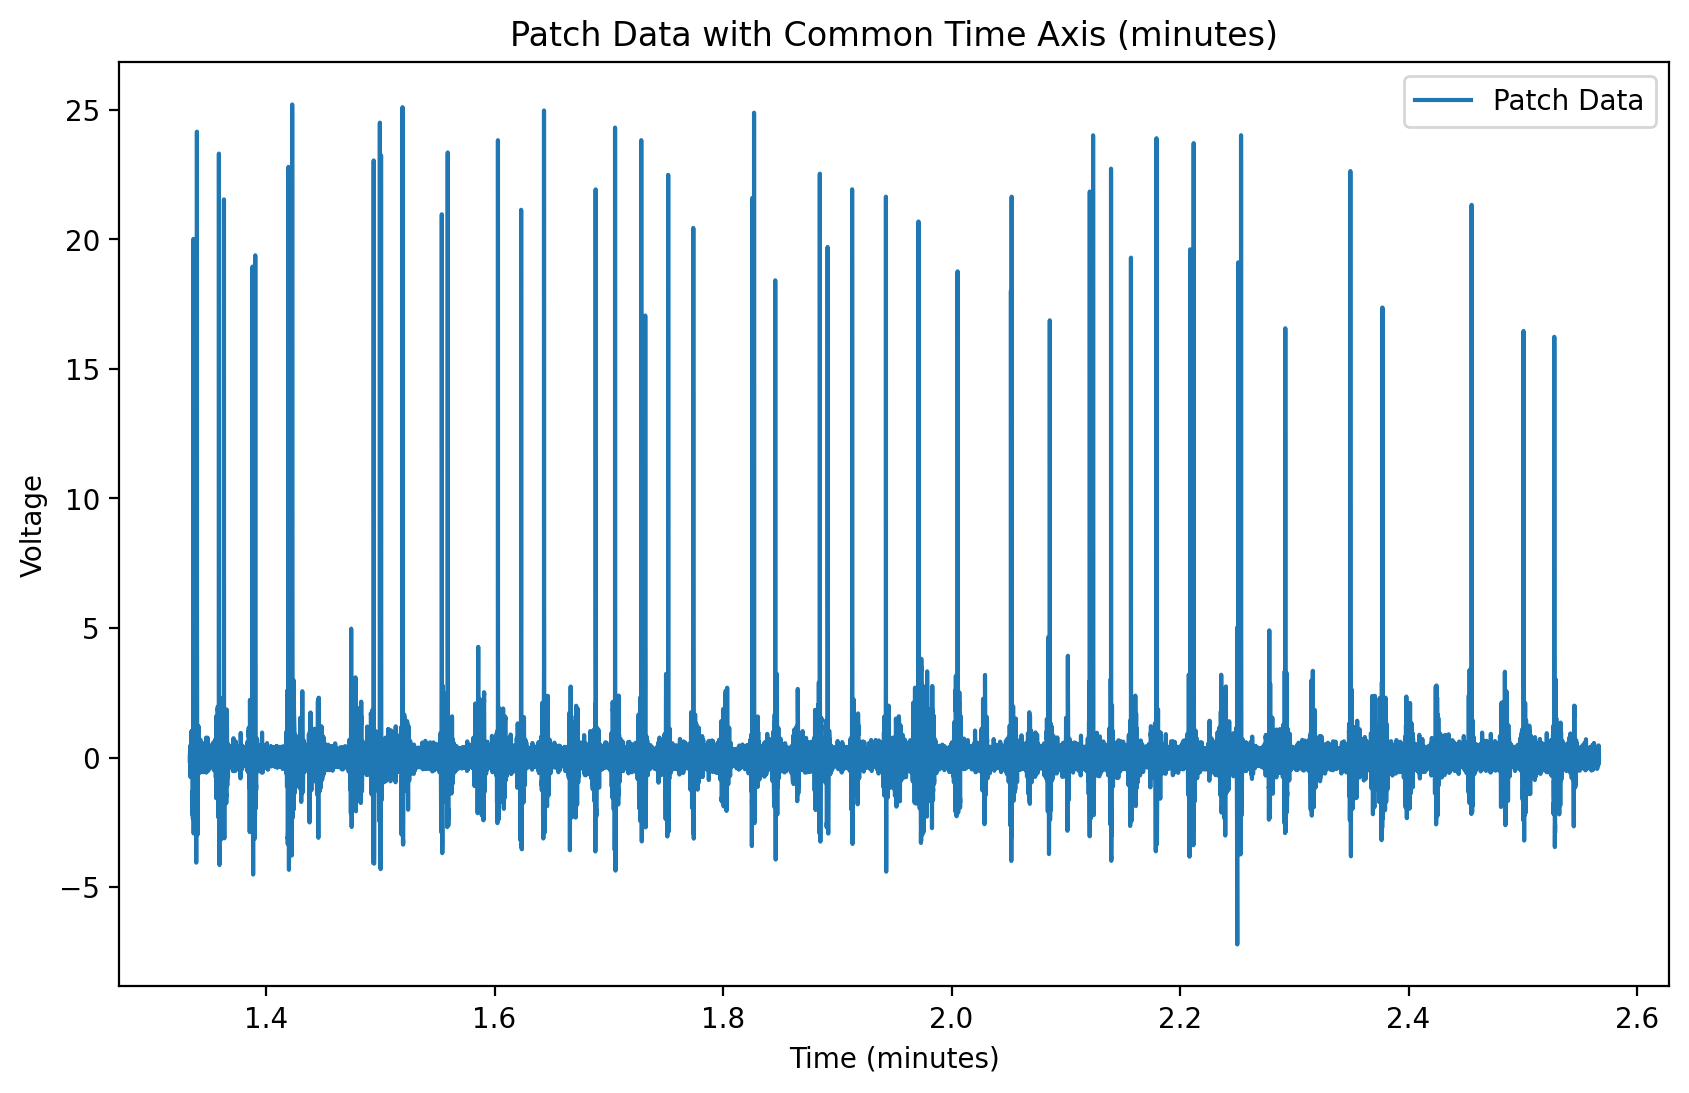

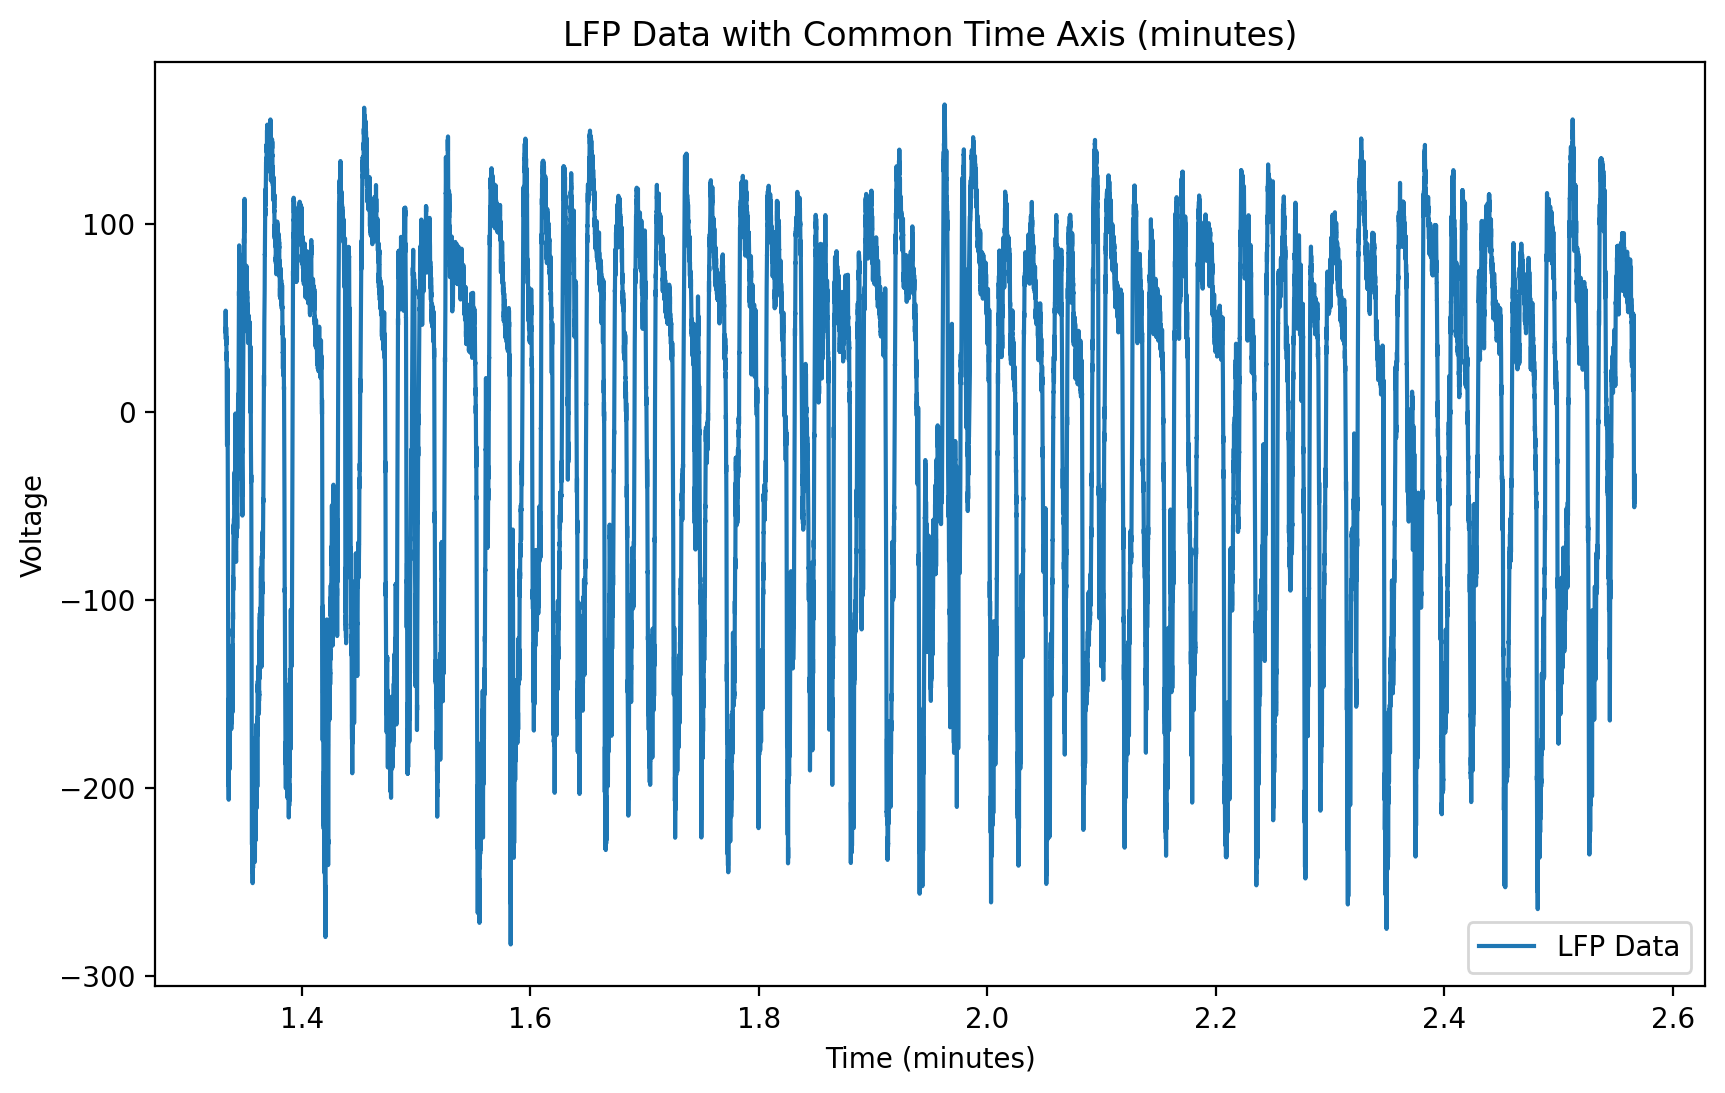

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

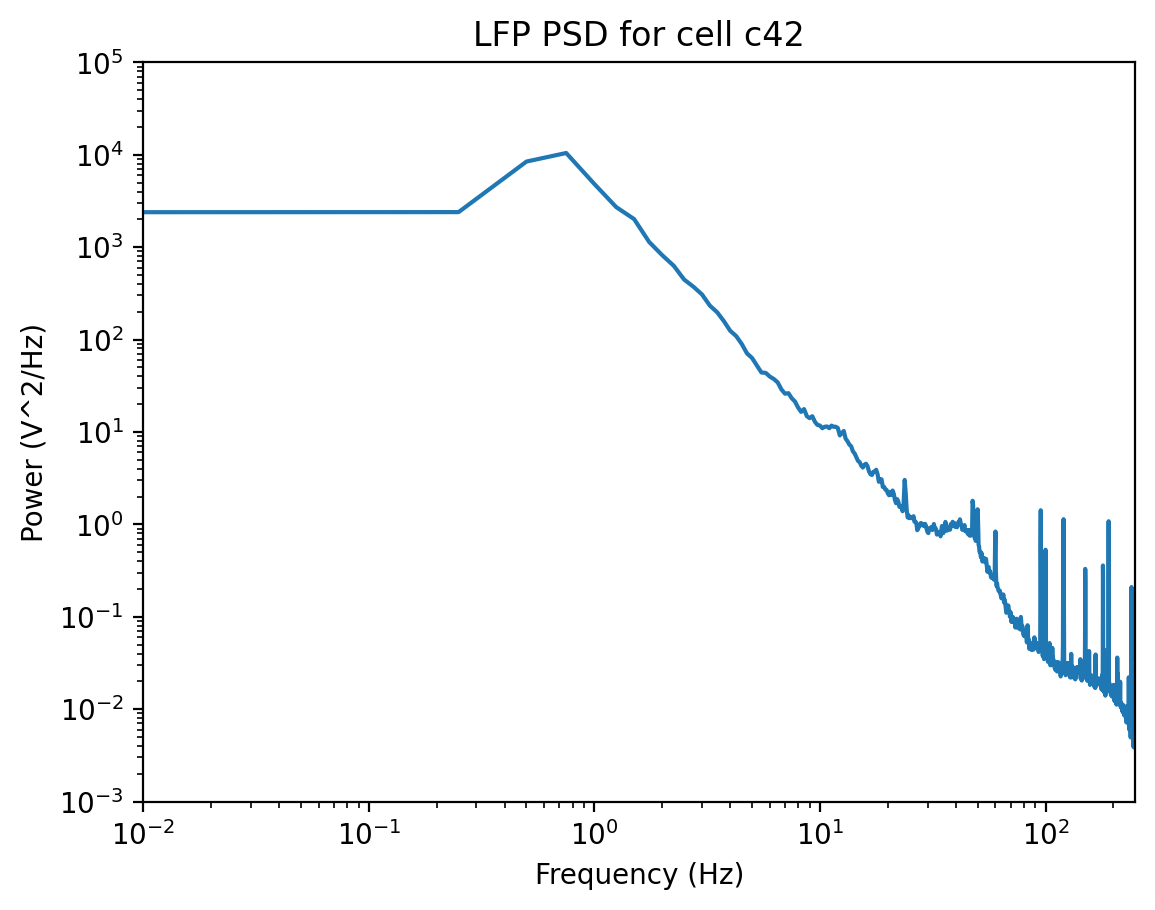

In [7]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


###### SLIDING WINDOWS APPROACH - Welch

In [8]:
model_welch, freqs_welch, window_times_welch = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method="welch"
)
summary_df_welch = model_welch.to_df()

Fitting model across 809 power spectra.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [9]:
summary_df_welch

,offset,exponent,error,r_squared
0,3.641588,2.573643,0.217935,0.939826
1,4.067211,3.018926,0.272241,0.916048
2,3.173315,2.571509,0.275493,0.899015
3,3.250240,2.641804,0.221723,0.932461
4,4.033338,2.860314,0.231103,0.927000
...,...,...,...,...
804,3.610121,2.756760,0.266562,0.903230
805,3.719529,2.843957,0.227169,0.941700
806,3.325782,2.616403,0.283783,0.851846
807,3.643108,2.779641,0.242261,0.910283


###### SLIDING WINDOWS APPROACH - Multitaper

In [10]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method="multitaper"
)

summary_df_multitaper = model_mt.to_df()

Fitting model across 809 power spectra.


## STEP 2: Detect spikes from patch data

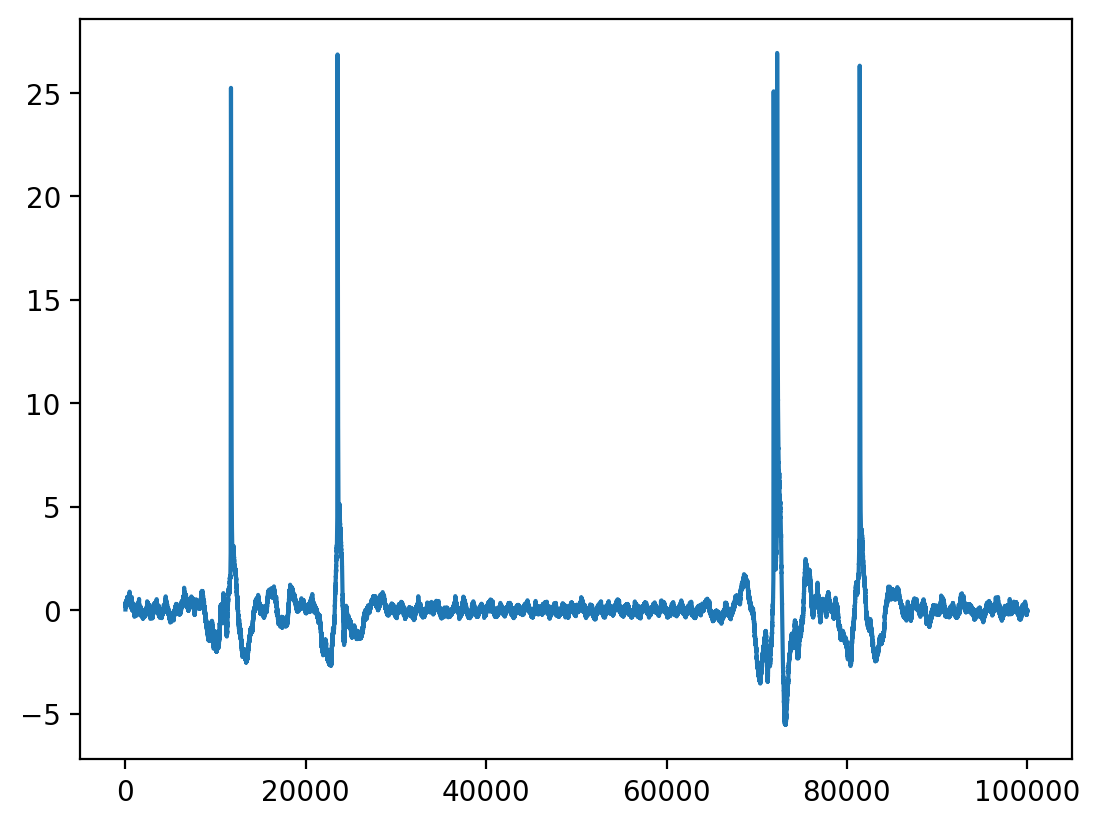

In [11]:
plt.plot(patch_filt[:100000] )

In [12]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [13]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1418 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


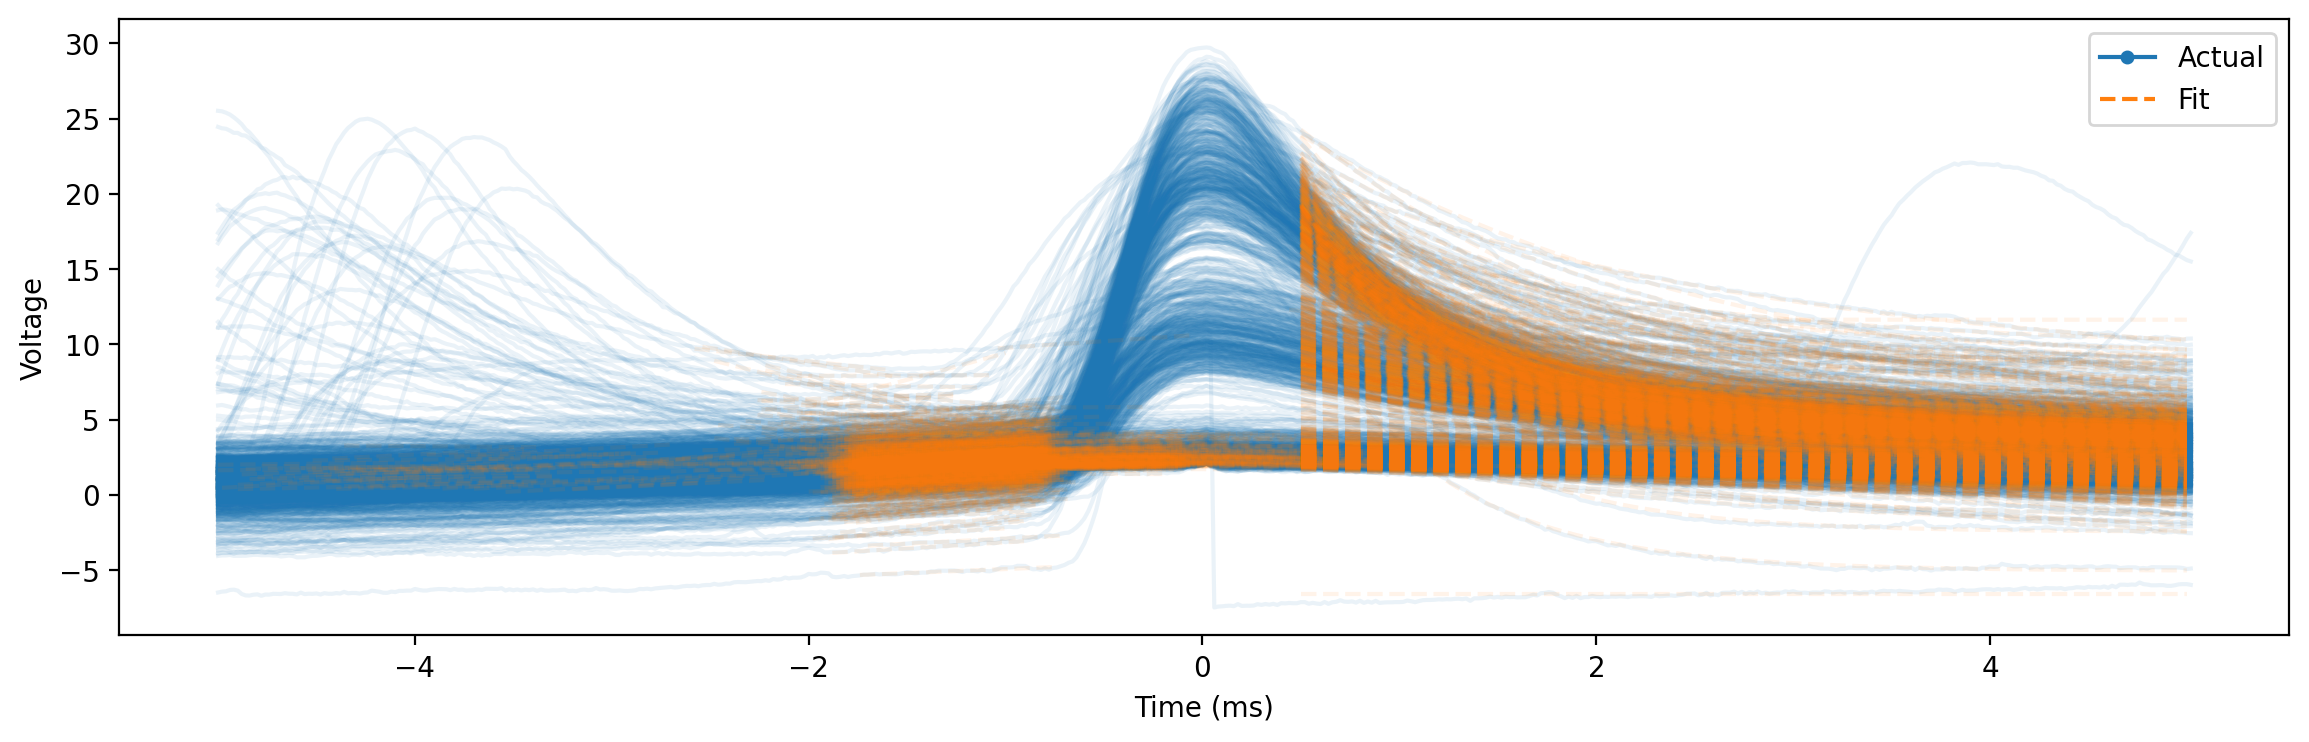

In [14]:
sp.plot()

### Filter spikes 

In [15]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [16]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [17]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,1.798995,72270,1444.709957,2
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,2.170699,149534,2989.252231,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,2.244713,40208636,803788.803062,984
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,3.227047,40217424,803964.479153,985
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,2.271959,40301801,805651.213512,986
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,3.543086,40311158,805838.264170,987


### Get spike times


In [18]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 3: Align spikes to lfp windows

In [19]:
spike_to_window_map = map_spikes_to_windows(spk_times_ms, spk_ids, window_times_welch, df_features['spk_id'], lfp_fs)


### Visualize spikes and lfp windows 

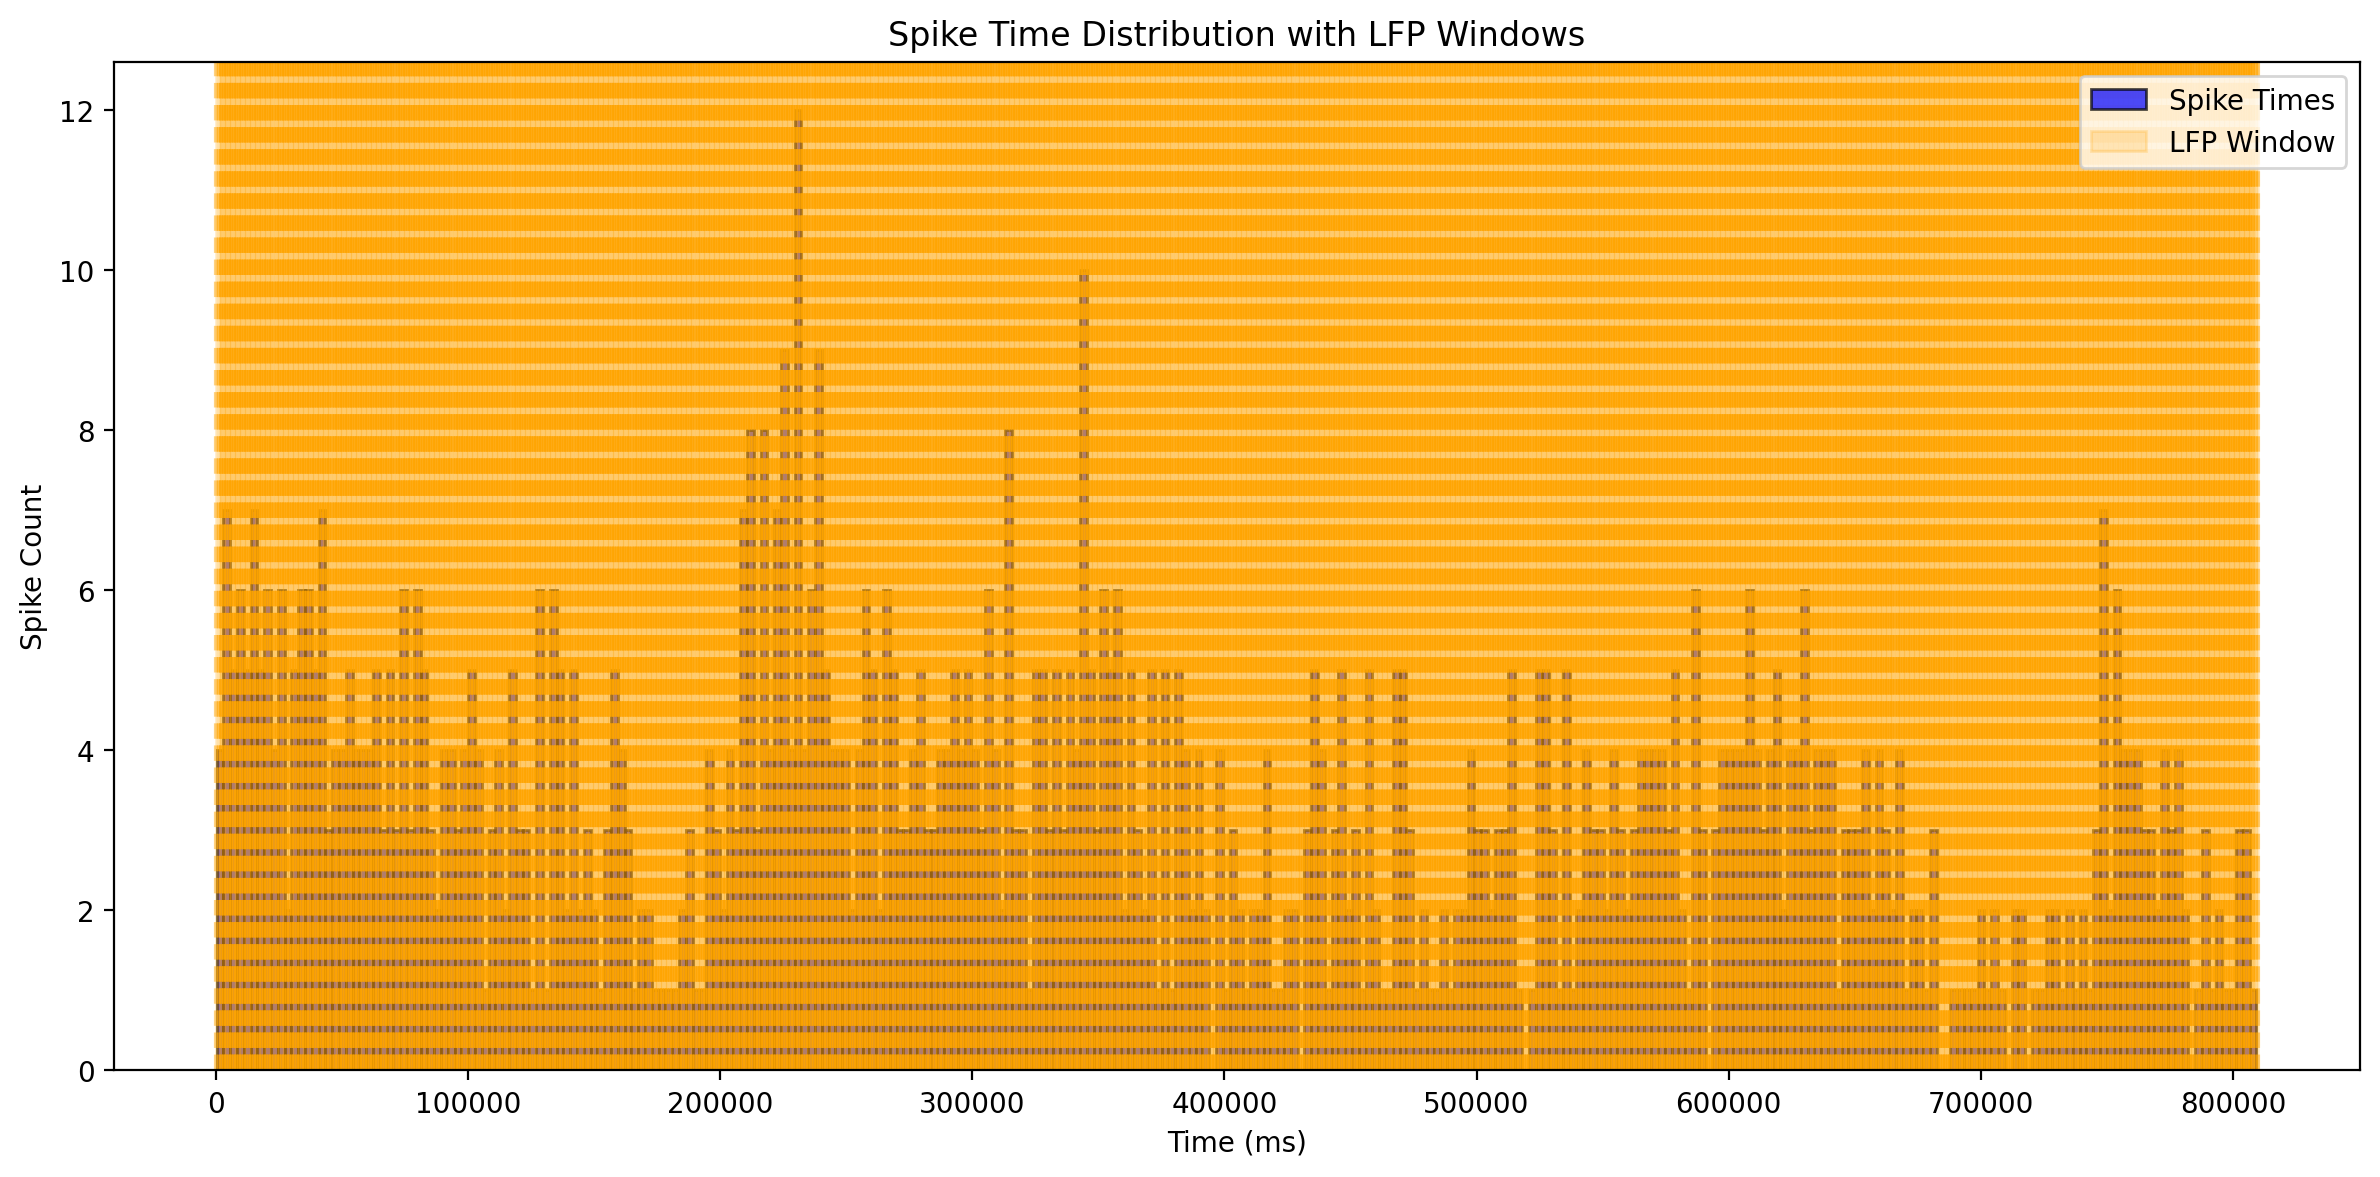

In [21]:
plot_spike_time_histogram(spk_times_ms,
    window_times_mt,
    lfp_fs)



## STEP 4: COMBINE SPIKE DATAFRAME WITH LFP FEATURES (FOR CURRENT WINDOW AND PREVIOUS WINDOW)

In [ ]:

df_combined_spk_lfp_welch = combine_spike_lfp_features(
    spike_data=df_features,
    summary_df=summary_df_welch,
    spike_to_window_map=spike_to_window_map
)
    
df_combined_spk_lfp_multit = combine_spike_lfp_features(
    spike_data=df_features,
    summary_df=summary_df_multitaper, 
    spike_to_window_map=spike_to_window_map
)

In [ ]:
summary_df_multitaper

In [ ]:
df_combined_spk_lfp_welch[:3000]


In [ ]:
df_combined_spk_lfp_multit[:3000]

### STEP 5: ANALYZE IF SPIKE WAVEFORM FEATURES CHANGE BASED ON CURRENT AND PREVIOUS LFP WINDOW - CORRELATIONS

In [ ]:
# Define spike and LFP features
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp','peak_amp', 'peak_width', 'peak_sharpness','exp_lambda', 	'exp_const', 'log_isi']
freq_bands = ['delta', 'theta','alpha', 'beta', 'gamma']
# Periodic features for mean correlation analysis
peak_features = (
    [f"lfp_current_{i}_peak_cf_mean" for i in freq_bands] +
    [f"lfp_current_{i}_peak_power_mean" for i in freq_bands] +
    [f"lfp_current_{i}_peak_bw_mean" for i in freq_bands]
)



lfp_features_current_mean = [
    'lfp_current_offset_mean',
    'lfp_current_exponent_mean',
    'lfp_current_r_squared_mean',
    'lfp_current_n_peaks_mean'
] + peak_features

# Same for previous if needed
peak_features_prev = (
    [f"lfp_previous_{i}_peak_cf_mean" for i in freq_bands] +
    [f"lfp_previous_{i}_peak_power_mean" for i in freq_bands] +
    [f"lfp_previous_{i}_peak_bw_mean" for i in freq_bands]
)

lfp_features_previous_mean = [
    'lfp_previous_offset_mean',
    'lfp_previous_exponent_mean',
    'lfp_previous_r_squared_mean',
    'lfp_previous_n_peaks_mean'
] + peak_features_prev


In [ ]:
df_combined_spk_lfp_multit

In [ ]:


df_current_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

df_current_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

In [ ]:
df_current_lfp_processed_multit

In [ ]:
df_current_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

In [ ]:
columns_to_drop = [
    'lfp_current_r_squared_mean',
    'lfp_current_n_peaks_mean',
    'lfp_current_theta_peak_power_mean',
    'lfp_current_theta_peak_cf_mean',
    'lfp_current_theta_peak_bw_mean',
    'lfp_current_alpha_peak_power_mean',
    'lfp_current_alpha_peak_cf_mean',
    'lfp_current_alpha_peak_bw_mean',
    'lfp_current_beta_peak_power_mean',
    'lfp_current_beta_peak_bw_mean',
    'lfp_current_beta_peak_cf_mean', 'spk_times_idx', 	'spk_times_ms', 	'spk_id', 'log_isi'
]

df_current_lfp_processed_multit.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [ ]:
df_current_lfp_processed_multit

In [ ]:
lfp_features_previous_mean

In [ ]:
"""

plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_welch,
    spike_features,
    lfp_features_current_mean, title = "Correlation heatmap Welch current LFP window")
plot_lfp_spk_correlation_heatmap(
    df_previous_lfp_processed_welch,
    spike_features,
    lfp_features_previous_mean, title = "Correlation heatmap Welch previous LFP window")""
"""


In [ ]:
lfp_features_current_mean

In [ ]:
df_current_lfp_processed_multit


In [ ]:
df_current_lfp_processed_multit

In [ ]:
valid_lfp_features = [col for col in lfp_features_current_mean if col in df_current_lfp_processed_multit.columns]
valid_spk_features = [col for col in spike_features if col in df_current_lfp_processed_multit.columns]

plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_multit,
    valid_spk_features ,
    valid_lfp_features,  title = "Correlation heatmap Multitaper current LFP window")


## STEP 6: Sensitivity analysis - see effects of welch vs multitaper with variation of hyperparameters for psd generation + fooof fitting

In [ ]:
fooof_param_grid = make_fooof_param_grid(
    max_n_peaks_list=[2, 3, 4],
    peak_threshold_list=[1.5, 2.0],
    aperiodic_modes=["fixed", "knee"]
)
window_lengths = [10, 20, 30]         # in seconds
methods = ["welch", "multitaper"]
bandwidths = [2.0, 4.0, 6.0]          # for multitaper (ignored by welch)
freq_range = (1,90)

In [ ]:
"""
# ----------------------------------------
# Run sensitivity analysis on LFP windows
# ----------------------------------------
sensitivity_results_df, foof_by_config = sensitivity_analysis(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    freq_range=freq_range,
    window_lengths=window_lengths,
    methods=methods,
    time_bandwidths=bandwidths,
    fooof_param_grid=fooof_param_grid,
    step_ratio=0.5,        # 50% overlap
    n_freqs=60,            # PSD resolution
    verbose=True
)
"""

In [ ]:
"""
#Save as pickle - comment out 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/sensitivity_results_df', 'wb') as file: 
    pickle.dump(sensitivity_results_df, file) 

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/foof_by_config', 'wb') as file: 
    pickle.dump(foof_by_config, file) """

In [ ]:
#Load pickle file 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/sensitivity_results_df', 'rb') as file:
    sensitivity_results_df = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/foof_by_config', 'rb') as file:
    foof_by_config = pickle.load(file)

In [ ]:
sensitivity_results_df

In [ ]:
sensitivity_results_df.groupby(['method', 'aperiodic_mode', 'window_length_sec'])[
    ['aperiodic_exponent', 'aperiodic_offset', 'gamma_peak_power', 'r_squared']
].describe()


In [ ]:
### Only show window length comparison
sensitivity_results_df.groupby(['method', 'window_length_sec'])[
    ['aperiodic_exponent', 'aperiodic_offset', 'gamma_peak_power']
].describe()



### Plot fooof fits - aside

In [ ]:
"""
save_foof_fit_examples(
    foof_by_config,
    output_dir="foof_fit_plots",
    n_examples=3  # how many example plots per config
)
"""

In [ ]:
#plot_fits_near_global_mean_and_outliers(sensitivity_results_df, foof_by_config)

In [ ]:
#plot_fits_near_global_mean_and_outliers(sensitivity_results_df, foof_by_config, metric="gamma_peak_power")